Aman Shaikh

F-02

**AIM: Evaluate Clustering results using Silhouette score and Davies-Bouldin Index**

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
# 1. load dataset
data = fetch_openml(name='diabetes', version=1, as_frame=True)
X = data.data
y = data.target
#KEEP ONLY NUMERIC COLUMNS
X=X.select_dtypes(include=["number"])
# 2. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k=2
model = KMeans(n_clusters=k, random_state=42)
cluster_labels = model.fit_predict(X_scaled)

silhouette = silhouette_score(X_scaled, cluster_labels)
db_index = davies_bouldin_score(X_scaled, cluster_labels)

print(f"For k= {k} clusters: ")
print(f"Silhouette Score: {silhouette: .4f}")
print(f"Davies-Bouldin Index: {db_index: .4f}")

For k= 2 clusters: 
Silhouette Score:  0.1646
Davies-Bouldin Index:  2.0994


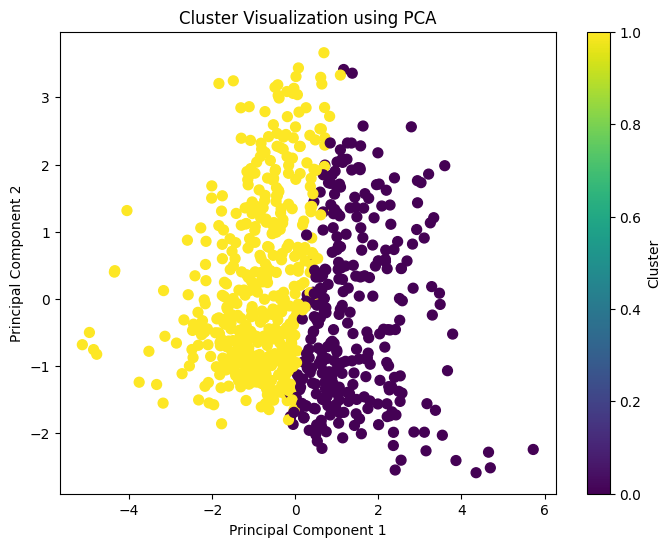

In [4]:
from sklearn.decomposition import PCA
#Reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
#plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=cluster_labels,
            cmap='viridis',
            s=50)
plt.title("Cluster Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()